## Predicting Floods in Sub-Saharan Africa Using Satellite Imagery and Computer Vision

# Project Objective

Developing a machine learning system that can predict floods 3 days in advance in Sub-Saharan Africa using Satellite imagery and related environmental data. The focus will be on demonstrating the application of computer vision techniques to extract spatial patterns predictive of flooding


# Motivation

- Floods are a major hazard in Sub-Saharan Africa, causing property damage, displacement, and loss of life.
- Early prediction enables disaster preparedness and humanitarian response.
- Satellite imagery is increasingly available, offering a rich visual dataset for flood prediction.
- This project demonstrates the use of computer vision pipelines in a real-world social-impact context.


In [64]:
!pip install flask ml4floods

python(90380) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached numpy-2.4.4-cp311-cp311-macosx_14_0_x86_64.whl.metadata (6.6 kB)
  Using cached numpy-2.4.4-cp311-cp311-macosx_14_0_x86_64.whl.metadata (6.6 kB)
  Using cached numpy-2.2.6-cp311-cp311-macosx_14_0_x86_64.whl.metadata (62 kB)
  Using cached numpy-2.2.6-cp311-cp311-macosx_14_0_x86_64.whl.metadata (62 kB)
  Using cached protobuf-6.33.6-cp39-abi3-macosx_10_9_universal2.whl.metadata (593 bytes)
  Using cached protobuf-6.33.6-cp39-abi3-macosx_10_9_universal2.whl.metadata (593 bytes)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)
Using cached numpy-2.2.6-cp311-cp311-macosx_14_0_x86_64.whl (6.9 MB)
Using cached numpy-2.2.6-cp311-cp311-macosx_14_0_x86_64.whl (6.9 MB)
Us

In [65]:
from ml4floods.visualization import plot_utils
from georeader import plot
from georeader.rasterio_reader import RasterioReader
from ml4floods.data.worldfloods.configs import BANDS_S2, COLORS_WORLDFLOODS

In [ ]:
# Load necessary libraries

# Core
import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import geemap

# Geospatial + raster
import rasterio
from rasterio.plot import show
import geopandas as gpd
import ee
import ml4floods
from ml4floods.data import worldfloods
from georeader import window_utils
from shapely.geometry import box
from ml4floods.visualization import plot_utils
from georeader import plot
from georeader.rasterio_reader import RasterioReader
from ml4floods.data.worldfloods.configs import BANDS_S2, COLORS_WORLDFLOODS

# ML utilities / metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

# Notebook display
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Imports loaded.")


Imports loaded.


## Download Relevant Region and Data

In [58]:
# Import the data from local location (flash drive)

DATA_ROOT = Path("/Volumes/Munashe/WorldFloodsv2")

print("DATA_ROOT:", DATA_ROOT)
print("Contents:", [p.name for p in DATA_ROOT.iterdir()])


DATA_ROOT: /Volumes/Munashe/WorldFloodsv2
Contents: ['.cache', 'test', 'README.md', '.gitattributes', 'dataset_metadata.csv', 'train', '._README.md', '.Rhistory', '._.Rhistory']


In [62]:
# Visualize event locations and splits using metadata

metadata_file = DATA_ROOT / "dataset_metadata.csv"
metadata = pd.read_csv(metadata_file)
metadata["geometry"] = metadata.apply(lambda row: window_utils.polygon_to_crs(box(*eval(row.bounds)),row.crs,"EPSG:4326"),
                                      axis=1)
metadata = gpd.GeoDataFrame(metadata,crs="EPSG:4326")
metadata = metadata.sort_values(["split","event id"])
metadata[["event id", "split", "s2_date","geometry"]].explore(column='split', cmap=['red','blue' ,'green'])

## Visualize sample train event

- A visualization of train event on the border of Zimbabwe and Mozambique

S2 used: /Volumes/Munashe/WorldFloodsv2/train/S2/EMSR349_09CHIMANIMANI_GRA_v2.tif
GT located: None
PERMANENTWATERJRC located: /Volumes/Munashe/WorldFloodsv2/train/PERMANENTWATERJRC/EMSR349_09CHIMANIMANI_GRA_v2.tif


S2 used: /Volumes/Munashe/WorldFloodsv2/train/S2/EMSR349_09CHIMANIMANI_GRA_v2.tif
GT located: None
PERMANENTWATERJRC located: /Volumes/Munashe/WorldFloodsv2/train/PERMANENTWATERJRC/EMSR349_09CHIMANIMANI_GRA_v2.tif


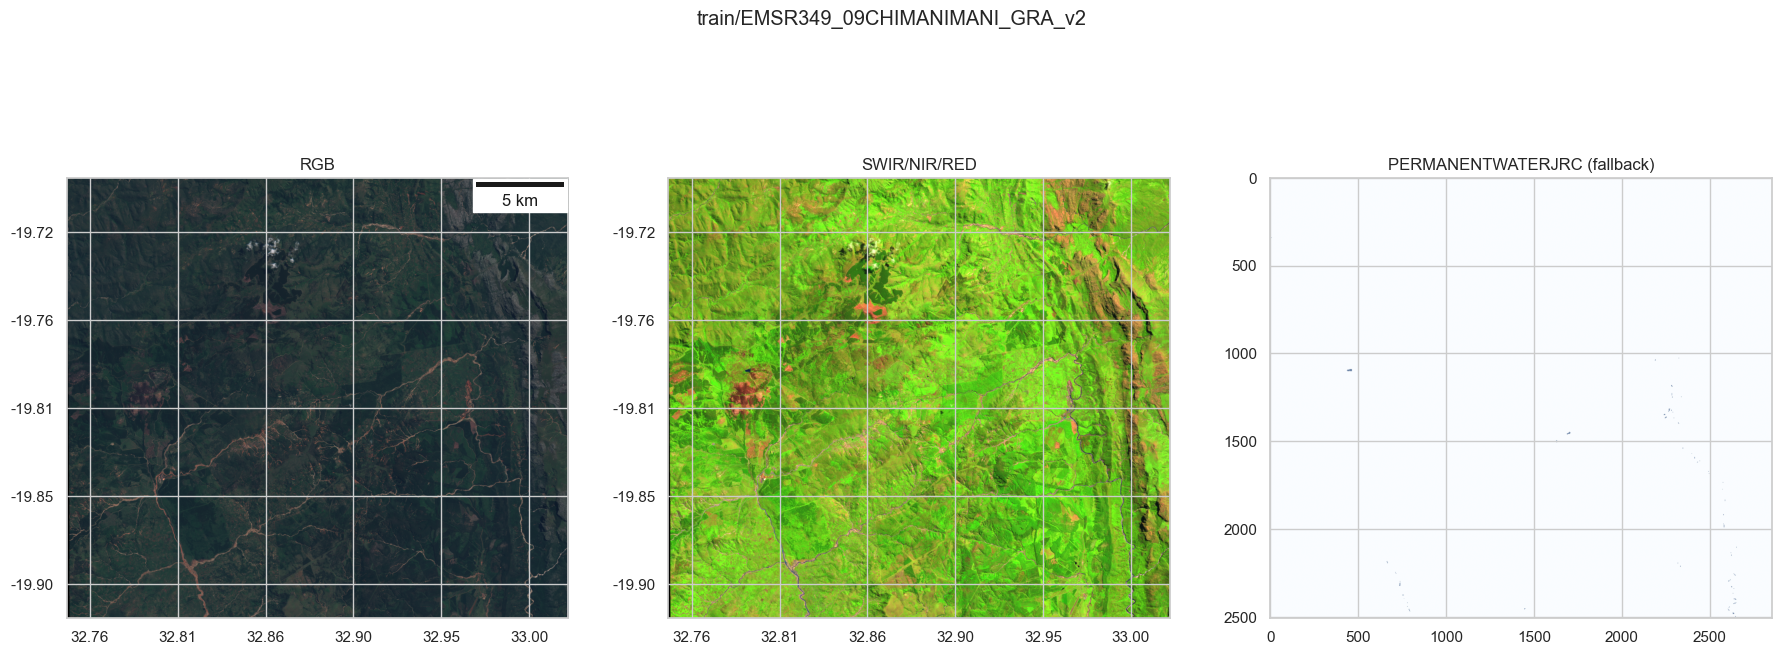

In [67]:
# Visualize the specified train event using ml4floods/georeader utilities (robust to missing GT)

EVENT_ID = "EMSR349_09CHIMANIMANI_GRA_v2"
SPLIT = "train"

# Bands to read and their indexes (use common S2 bands)
s2_bands_read = ["B2", "B3", "B4", "B8", "B11", "B12"]
s2_band_indexes = [BANDS_S2.index(b) + 1 for b in s2_bands_read]

# Build candidate paths
s2_candidate = DATA_ROOT / SPLIT / "S2" / f"{EVENT_ID}.tif"
possible_s2_dir = DATA_ROOT / SPLIT / "S2"

# Find S2 file (exact or EMSR prefix fallback)
if s2_candidate.exists():
    s2_file = s2_candidate
else:
    prefix = EVENT_ID.split("_")[0]
    s2_list = sorted(possible_s2_dir.glob(f"{prefix}*.tif")) if possible_s2_dir.exists() else []
    s2_file = s2_list[0] if s2_list else None

# Search for GT: prefer same split, else look in test split, else None
gt_file_exact = DATA_ROOT / SPLIT / "gt" / f"{EVENT_ID}.tif"
gt_file = gt_file_exact if gt_file_exact.exists() else None
if gt_file is None:
    # search by prefix in train gt
    train_gt_dir = DATA_ROOT / SPLIT / "gt"
    prefix = EVENT_ID.split("_")[0]
    if train_gt_dir.exists():
        cand = sorted(train_gt_dir.glob(f"{prefix}*.tif"))
        if cand:
            gt_file = cand[0]

if gt_file is None:
    # search in test gt folder (sometimes GT only in test)
    test_gt_dir = DATA_ROOT / "test" / "gt"
    if test_gt_dir.exists():
        cand = sorted(test_gt_dir.glob(f"{prefix}*.tif"))
        if cand:
            gt_file = cand[0]

# PERMANENTWATERJRC candidate
pw_candidate = DATA_ROOT / SPLIT / "PERMANENTWATERJRC" / f"{EVENT_ID}.tif"
if pw_candidate.exists():
    pw_file = pw_candidate
else:
    pw_dir = DATA_ROOT / SPLIT / "PERMANENTWATERJRC"
    pw_list = sorted(pw_dir.glob(f"{prefix}*.tif")) if pw_dir.exists() else []
    pw_file = pw_list[0] if pw_list else None

print(f"S2 used: {s2_file}")
print(f"GT located: {gt_file}")
print(f"PERMANENTWATERJRC located: {pw_file}")

if s2_file is None or not Path(s2_file).exists():
    raise FileNotFoundError(f"No Sentinel-2 file found for event {EVENT_ID} in {SPLIT}/S2 or by prefix")

# Load S2 with RasterioReader
rst = RasterioReader(str(s2_file), indexes=s2_band_indexes).load()
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# Panel 1: RGB (B4,B3,B2)
plot.show((rst.isel({"band": [2, 1, 0]}) / 3_500).clip(0, 1), ax=axes[0], add_scalebar=True, title="RGB")

# Panel 2: SWIR/NIR/RED (B11,B8,B4)
plot.show((rst.isel({"band": [4, 3, 2]}) / 3_500).clip(0, 1), ax=axes[1], title="SWIR/NIR/RED")

# Panel 3: use GT if found; else use PERMANENTWATERJRC if found; else show message
if gt_file is not None and Path(gt_file).exists():
    rst_gt = RasterioReader(str(gt_file)).load()
    v1gt = rst_gt.isel({"band": 1}).copy()
    v1gt.values[rst_gt.values[0] == 2] = 3
    plot.plot_segmentation_mask(v1gt, color_array=COLORS_WORLDFLOODS,
                                interpretation_array=plot_utils.INTERPRETATION_WORLDFLOODS,
                                ax=axes[2])
    axes[2].set_title("GT (from gt folder)")
elif pw_file is not None and Path(pw_file).exists():
    with rasterio.open(pw_file) as src_pw:
        pw = src_pw.read(1)
    pw_mask = (pw > 0).astype(float)
    axes[2].imshow(pw_mask, cmap='Blues', alpha=0.6)
    axes[2].set_title('PERMANENTWATERJRC (fallback)')
else:
    axes[2].text(0.5, 0.5, 'No GT or PERMANENTWATERJRC available for this event', ha='center', va='center')
    axes[2].set_axis_off()

plt.suptitle(f"{SPLIT}/{EVENT_ID}")
plt.show()

S2 used: /Volumes/Munashe/WorldFloodsv2/test/S2/EMSR347_06MWANZA_DEL_v1.tif
GT located: /Volumes/Munashe/WorldFloodsv2/test/gt/EMSR347_06MWANZA_DEL_v1.tif
PERMANENTWATERJRC located: /Volumes/Munashe/WorldFloodsv2/test/PERMANENTWATERJRC/EMSR347_06MWANZA_DEL_v1.tif


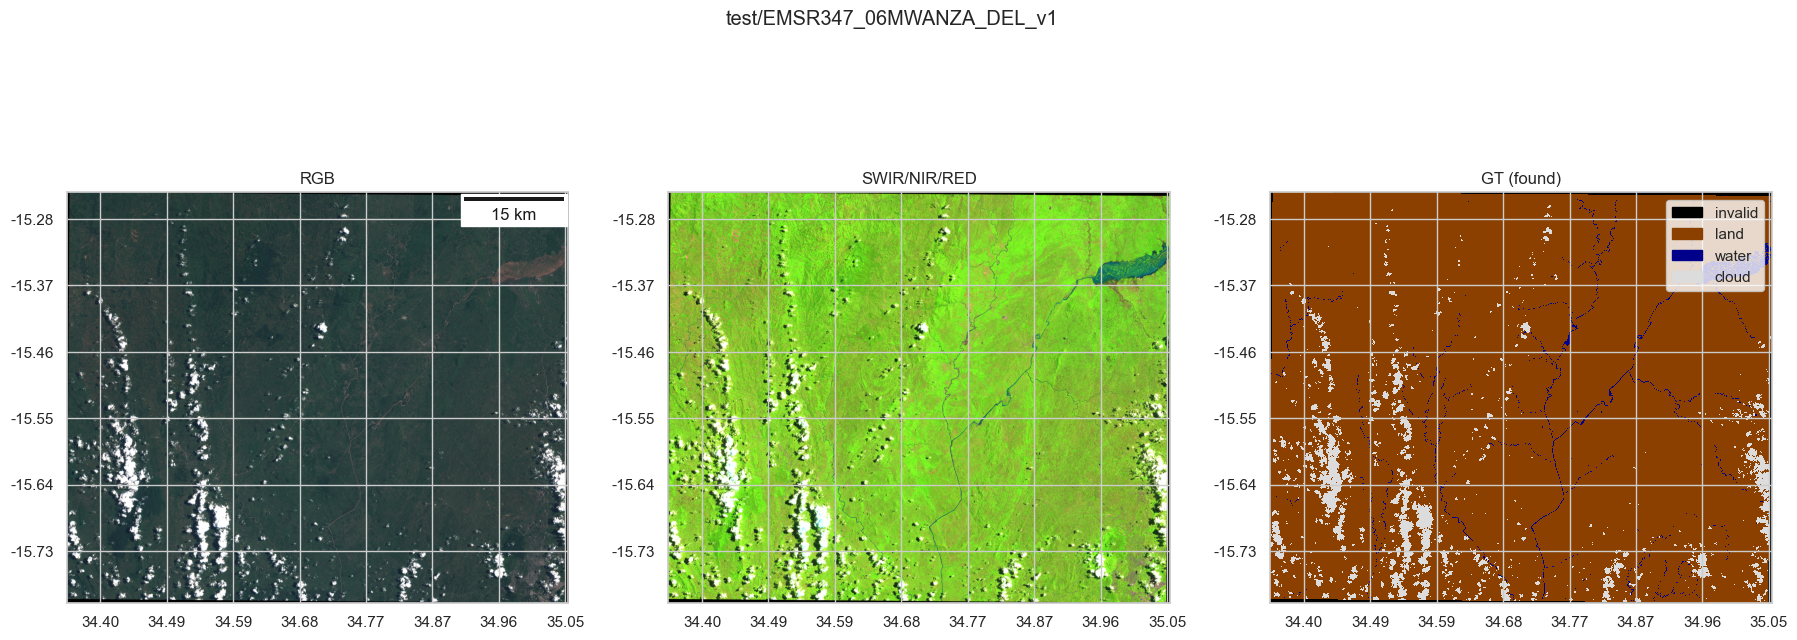

In [68]:
# Visualization of sample test event in Malawi

EVENT_ID = "EMSR347_06MWANZA_DEL_v1"
SPLIT = "test"

# Bands and indexes
s2_bands_read = ["B2", "B3", "B4", "B8", "B11", "B12"]
s2_band_indexes = [BANDS_S2.index(b) + 1 for b in s2_bands_read]

# Candidate paths
s2_candidate = DATA_ROOT / SPLIT / "S2" / f"{EVENT_ID}.tif"
possible_s2_dir = DATA_ROOT / SPLIT / "S2"

# Find S2 file (exact or EMSR prefix fallback)
if s2_candidate.exists():
    s2_file = s2_candidate
else:
    prefix = EVENT_ID.split("_")[0]
    s2_list = sorted(possible_s2_dir.glob(f"{prefix}*.tif")) if possible_s2_dir.exists() else []
    s2_file = s2_list[0] if s2_list else None

# Search for GT: prefer same split, else look in train split
gt_file_exact = DATA_ROOT / SPLIT / "gt" / f"{EVENT_ID}.tif"
gt_file = gt_file_exact if gt_file_exact.exists() else None
if gt_file is None:
    test_gt_dir = DATA_ROOT / SPLIT / "gt"
    prefix = EVENT_ID.split("_")[0]
    if test_gt_dir.exists():
        cand = sorted(test_gt_dir.glob(f"{prefix}*.tif"))
        if cand:
            gt_file = cand[0]
if gt_file is None:
    train_gt_dir = DATA_ROOT / "train" / "gt"
    if train_gt_dir.exists():
        cand = sorted(train_gt_dir.glob(f"{prefix}*.tif"))
        if cand:
            gt_file = cand[0]

# PERMANENTWATERJRC candidate
pw_candidate = DATA_ROOT / SPLIT / "PERMANENTWATERJRC" / f"{EVENT_ID}.tif"
if pw_candidate.exists():
    pw_file = pw_candidate
else:
    pw_dir = DATA_ROOT / SPLIT / "PERMANENTWATERJRC"
    pw_list = sorted(pw_dir.glob(f"{prefix}*.tif")) if pw_dir.exists() else []
    pw_file = pw_list[0] if pw_list else None

print(f"S2 used: {s2_file}")
print(f"GT located: {gt_file}")
print(f"PERMANENTWATERJRC located: {pw_file}")

if s2_file is None or not Path(s2_file).exists():
    raise FileNotFoundError(f"No Sentinel-2 file found for event {EVENT_ID} in {SPLIT}/S2 or by prefix")

# Load S2 with RasterioReader
rst = RasterioReader(str(s2_file), indexes=s2_band_indexes).load()
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# Panel 1: RGB (B4,B3,B2)
plot.show((rst.isel({"band": [2, 1, 0]}) / 3_500).clip(0, 1), ax=axes[0], add_scalebar=True, title="RGB")

# Panel 2: SWIR/NIR/RED (B11,B8,B4)
plot.show((rst.isel({"band": [4, 3, 2]}) / 3_500).clip(0, 1), ax=axes[1], title="SWIR/NIR/RED")

# Panel 3: GT if found; else PERMANENTWATERJRC; else message
if gt_file is not None and Path(gt_file).exists():
    rst_gt = RasterioReader(str(gt_file)).load()
    v1gt = rst_gt.isel({"band": 1}).copy()
    v1gt.values[rst_gt.values[0] == 2] = 3
    plot.plot_segmentation_mask(v1gt, color_array=COLORS_WORLDFLOODS,
                                interpretation_array=plot_utils.INTERPRETATION_WORLDFLOODS,
                                ax=axes[2])
    axes[2].set_title("GT (found)")
elif pw_file is not None and Path(pw_file).exists():
    with rasterio.open(pw_file) as src_pw:
        pw = src_pw.read(1)
    pw_mask = (pw > 0).astype(float)
    axes[2].imshow(pw_mask, cmap='Blues', alpha=0.6)
    axes[2].set_title('PERMANENTWATERJRC (fallback)')
else:
    axes[2].text(0.5, 0.5, 'No GT or PERMANENTWATERJRC available for this event', ha='center', va='center')
    axes[2].set_axis_off()

plt.suptitle(f"{SPLIT}/{EVENT_ID}")
plt.show()

The train folder does not contain the ground truth (gt). These may be generated later by comparing the S2 image to the PERMANENTWATERJRC mask. For EDA, the focus will be on the test folder first